## Read output files

In [1]:
import awkward as ak
import numpy as np
import uproot
import os

/cvmfs/cms.cern.ch/slc7_amd64_gcc10/external/py3-setuptools/60.9.3-ddcab3b6a742c72fed5554de8ccaaf18/lib/python3.9/site-packages/_distutils_hack/__init__.py:17: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/cvmfs/cms.cern.ch/slc7_amd64_gcc10/external/py3-setuptools/60.9.3-ddcab3b6a742c72fed5554de8ccaaf18/lib/python3.9/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


In [2]:
basedir = {
    c: '../condor/output/mc/2018/'+c for c in os.listdir('../condor/output/mc/2018/')
}
filepath={c: [] for c in basedir}
for c in basedir:
    for (current_path, dirs, files) in os.walk(basedir[c]):
        for f in files:
            if f.endswith('.parq'):
                filepath[c].append(os.path.join(current_path, f))

filepath

{'QCD': ['../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/57.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/55.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/42.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/49.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/53.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/10.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/36.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/17.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/5.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/7.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/33.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/18.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/6.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/37.parq',
  '../condor/output/mc/2018/QCD/QCD_HT200to300_TuneCP5/44.parq',
  '../condor/output/m

In [3]:
events = {
    k: [] for k in filepath
}
for k, v in filepath.items():
    for f in v:
        array = ak.from_parquet(f)
        if len(array)>0:
            events[k].append(array)
    events[k] = ak.concatenate(events[k], axis=0)

events

{'QCD': <Array [{AK8jet_msoftdrop: [, ... ] type='4880 * {"AK8jet_msoftdrop": option[var...'>,
 'ZpToHGamma': <Array [{AK8jet_pt: [, ... gen_MET_pt: 51.2}] type='173452 * {"AK8jet_pt": optio...'>,
 'ZJetsToQQ': <Array [{AK8jet_pt: [, ... ] type='871 * {"AK8jet_pt": option[var * float32], "A...'>,
 'WJetsToQQ': <Array [{AK8jet_pt: [, ... ] type='2506 * {"AK8jet_pt": option[var * float32], "...'>,
 'GJets': <Array [{AK8jet_pt: [, ... ] type='56698 * {"AK8jet_pt": option[var * float32], ...'>}

## Start plotting

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

mpl.rcParams['axes.prop_cycle'] = cycler(color=['red', 'blue', 'green', 'cyan', 'darkorange', 'black', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue'])

In [5]:
for m in [1000, 2000, 3000]:
    cut = ak.flatten(
        (events['ZpToHGamma']["gen_Z'_mass"] > m-10) &
        (events['ZpToHGamma']["gen_Z'_mass"] < m+10)
    )
    events[f'ZpToHGamma_{m}'] = events['ZpToHGamma'][cut]

del events['ZpToHGamma']

In [12]:
def plot(arrays, x_name: str, cuts=None, year=2018, flatten=False, bins=40, x_min=0, x_max=2000, density=True, stack=False, overflow=True):
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}    
    
    ## canvas initializing
    #colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    #mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    plt.figure(figsize=(8,8))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=year, ax=ax)
    
    ## plot
    for (k,v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        if flatten:
            v = ak.flatten(v, axis=-1)
        values = ak.fill_none(v, -999)
        
        hist.fill(values)
        h, var = hist.view(flow=overflow).value, hist.view(flow=overflow).variance
        if overflow: ## h, var also include underflow bins but in plots usually no underflow data
            ## And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
            h[-2]+=h[-1]; var[-2]+=var[-1]
            h = h[1:-1]; var = var[1:-1]
        err = np.sqrt(var)
        hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label=k, histtype='step', density=density, stack=stack)
        # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 


    ## axises
    plt.xlim(x_min, x_max)
    plt.ylim(0, ax.get_ylim()[1]*1.2)
    ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        plt.ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
    plt.xlabel(x_name, fontsize=22, ha='right', x=1)

    plt.xticks(size=16)
    plt.yticks(size=16)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    plt.legend(loc="best", ncol=2, frameon=False, fontsize=18)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
    suffix = ''
    if density==True:   suffix += '_AU'
    if stack==True:     suffix += '_stack'
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig("./plots/"+x_name+suffix+".pdf", bbox_inches='tight')
    plt.show()

In [13]:
print(events['ZpToHGamma_1000'].fields)

['AK8jet_pt', 'AK8jet_eta', 'AK8jet_msoftdrop', 'AK8jet_phi', 'AK8jet_mass', 'photon_pt', 'photon_eta', 'photon_phi', 'photon_mass', 'event_MET_pt', 'photon-jet_pt', 'photon-jet_eta', 'photon-jet_phi', 'photon-jet_mass', 'photon-jet_deltaR', "gen_Z'_pt", "gen_Z'_eta", "gen_Z'_pdgId", "gen_Z'_phi", "gen_Z'_mass", 'gen_H_pt', 'gen_H_eta', 'gen_H_pdgId', 'gen_H_phi', 'gen_H_mass', 'gen_a_pt', 'gen_a_eta', 'gen_a_pdgId', 'gen_a_phi', 'gen_a_mass', 'gen_WW_pt', 'gen_WW_eta', 'gen_WW_pdgId', 'gen_WW_phi', 'gen_WW_mass', 'gen_WW_childs_pt', 'gen_WW_childs_eta', 'gen_WW_childs_pdgId', 'gen_WW_childs_phi', 'gen_WW_childs_mass', 'gen_H_a', 'gen_deltaR_H_a', 'gen_HWW_decay_mode', 'gen_HWW_a', 'gen_MET_pt']


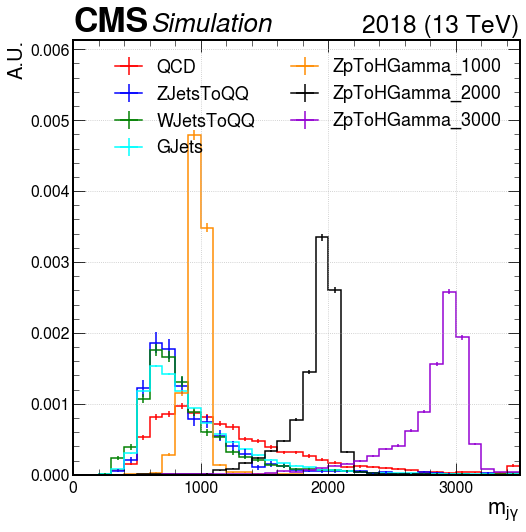

In [14]:
arrays={c: events[c]['photon-jet_mass'] for c in events}
plot(arrays, x_name=r'$m_{j\gamma}$', flatten=True, x_max=3500, bins=35)

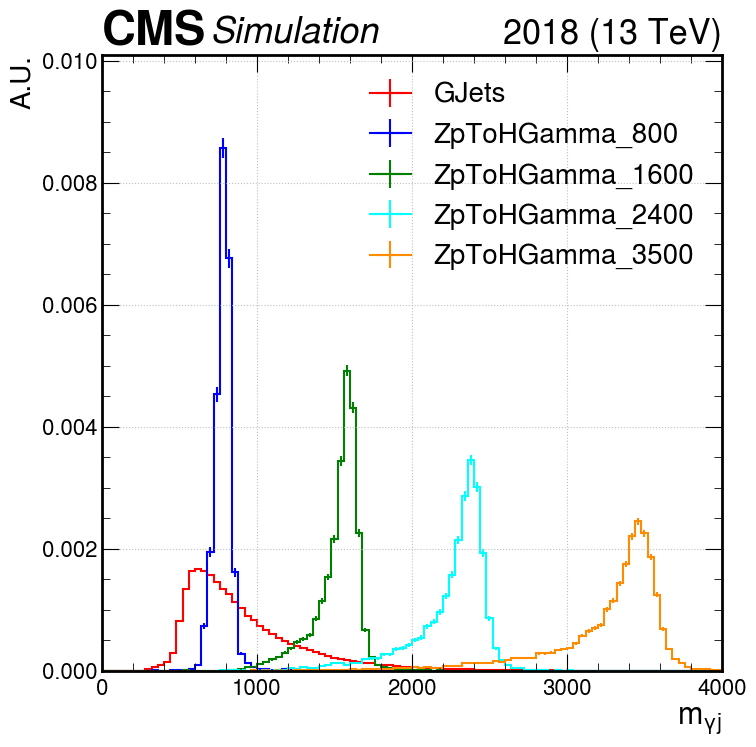

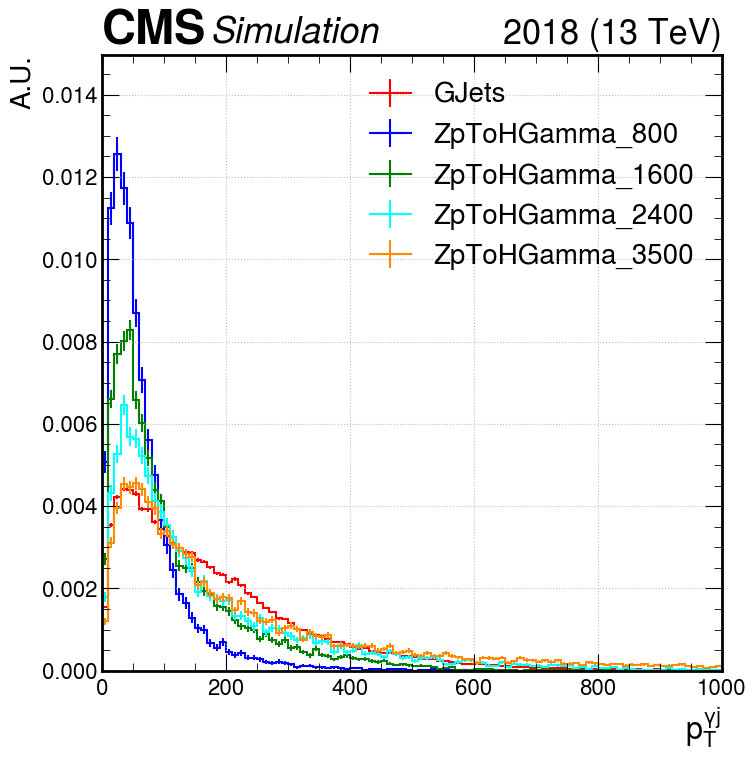

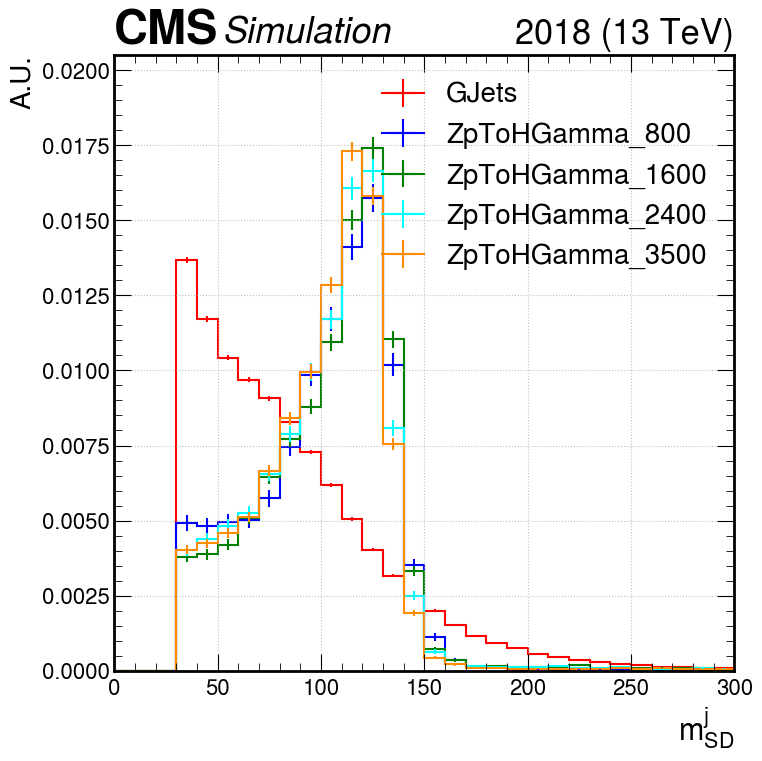

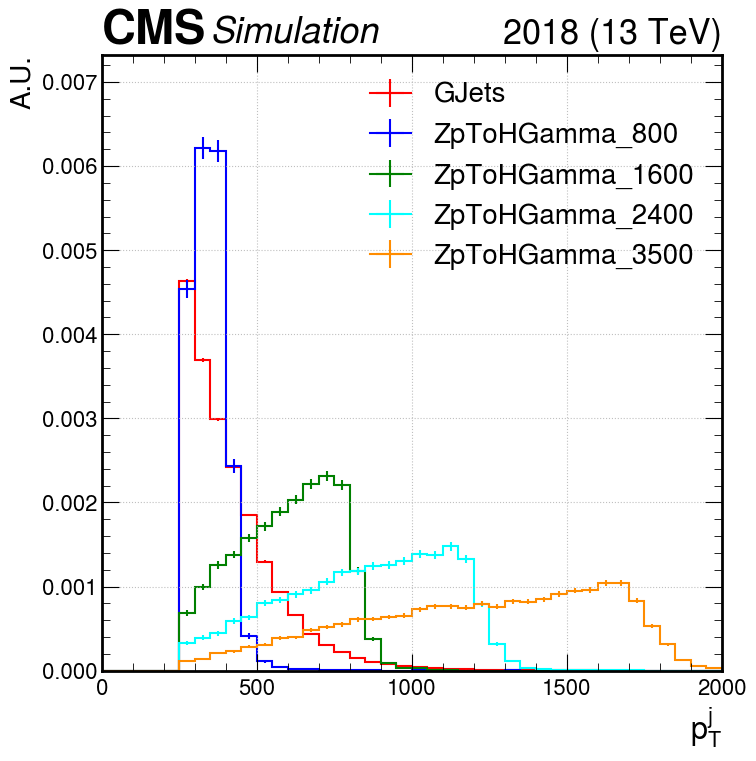

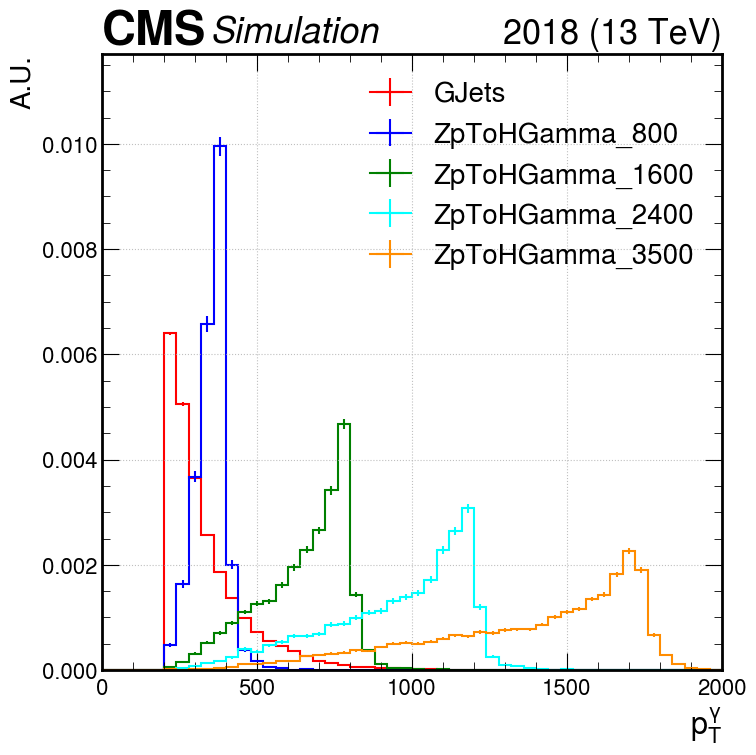

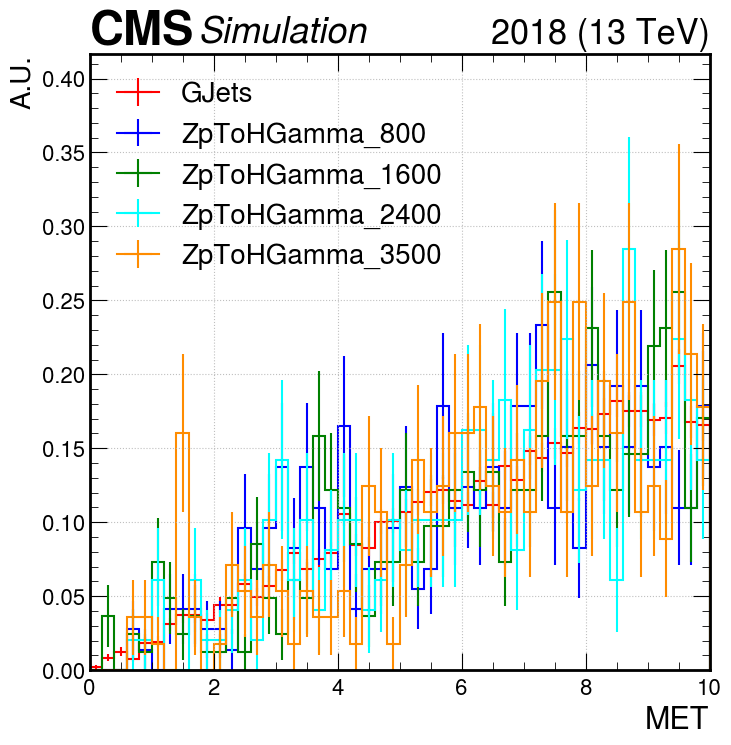

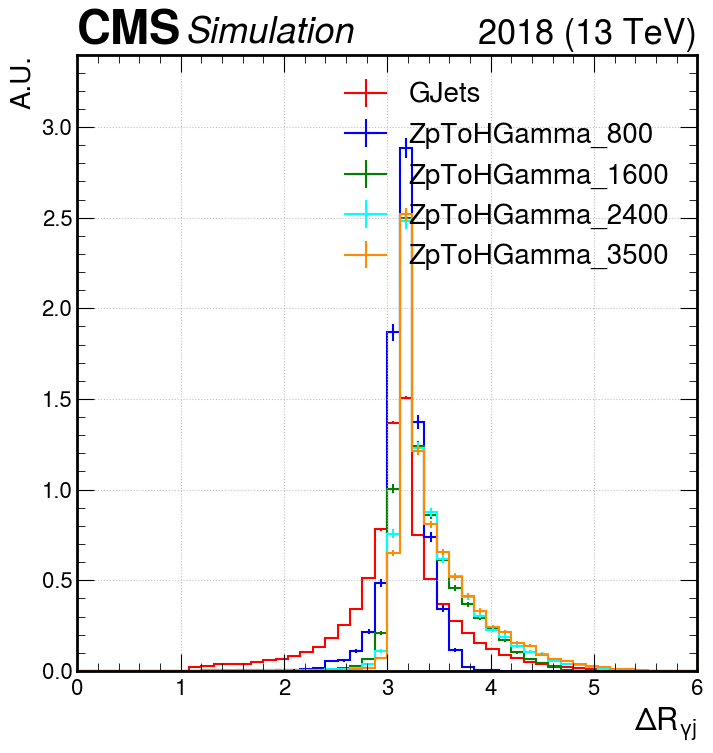

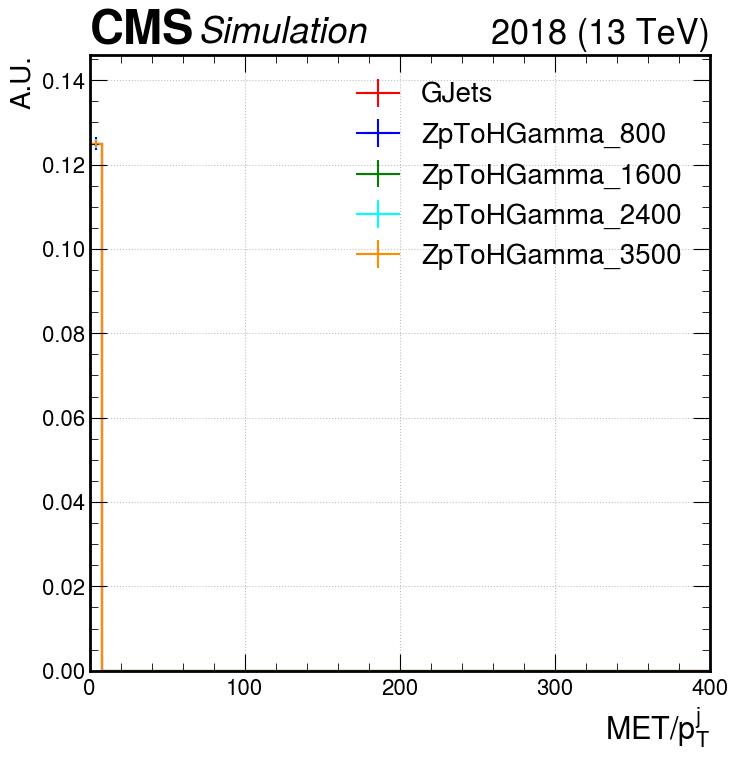

In [103]:
plot(events=output, variable='photon-jet_mass', latex=r'$m_{\gamma j}$', flatten=False, bins=100, x_min=0, x_max=4000, density=True, stack=False, year=2018)
plot(events=output, variable='photon-jet_pt', latex=r'$p_T^{\gamma j}$', flatten=False, bins=100, x_min=0, x_max=1000, density=True, stack=False, year=2018)
plot(events=output, variable='AK8jet_msoftdrop', latex=r'$m_{SD}^{j}$', flatten=True, bins=30, x_min=0, x_max=300, density=True, stack=False, year=2018)
plot(events=output, variable='AK8jet_pt', latex=r'$p_T^j$', flatten=True, bins=40, x_min=0, x_max=2000, density=True, stack=False, year=2018)
plot(events=output, variable='photon_pt', latex=r'$p_T^\gamma$', flatten=True, bins=50, x_min=0, x_max=2000, density=True, stack=False, year=2018)
plot(events=output, variable='event_MET_pt', latex='MET', flatten=False, bins=50, x_min=0, x_max=400, density=True, stack=False, year=2018)
#plot(events=output, variable='gen_MET_pt', latex=r'$MET^{gen}$', flatten=False, bins=50, x_min=0, x_max=400, density=True, stack=False, year=2018)
plot(events=output, variable='photon-jet_deltaR', latex=r'$\Delta R_{\gamma j}$', flatten=False, bins=50, x_min=0, x_max=6, density=True, stack=False, year=2018)
plot(events=output, variable='MET_pt_H', latex=r'$MET/p_T^{j}$', flatten=True, bins=50, x_min=0, x_max=400, density=True, stack=False, year=2018)